In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
model_path = "../models/best_yolo8m_ball-detection.pt"
model = YOLO(model_path)

In [3]:
video_path = "../input_video/input_1.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
num_samples = 10  # ganti jadi 5 kalau mau lebih sedikit

# Ambil frame secara merata
frame_indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

cap.release()

print(f"Berhasil ambil {len(frames)} frame")

Berhasil ambil 10 frame


In [4]:
results = model(frames, imgsz=1280, conf=0.25)


0: 800x1280 (no detections), 2761.9ms
1: 800x1280 (no detections), 2761.9ms
2: 800x1280 1 ball, 2761.9ms
3: 800x1280 (no detections), 2761.9ms
4: 800x1280 (no detections), 2761.9ms
5: 800x1280 (no detections), 2761.9ms
6: 800x1280 (no detections), 2761.9ms
7: 800x1280 (no detections), 2761.9ms
8: 800x1280 (no detections), 2761.9ms
9: 800x1280 (no detections), 2761.9ms
Speed: 21.1ms preprocess, 2761.9ms inference, 3.2ms postprocess per image at shape (1, 3, 800, 1280)


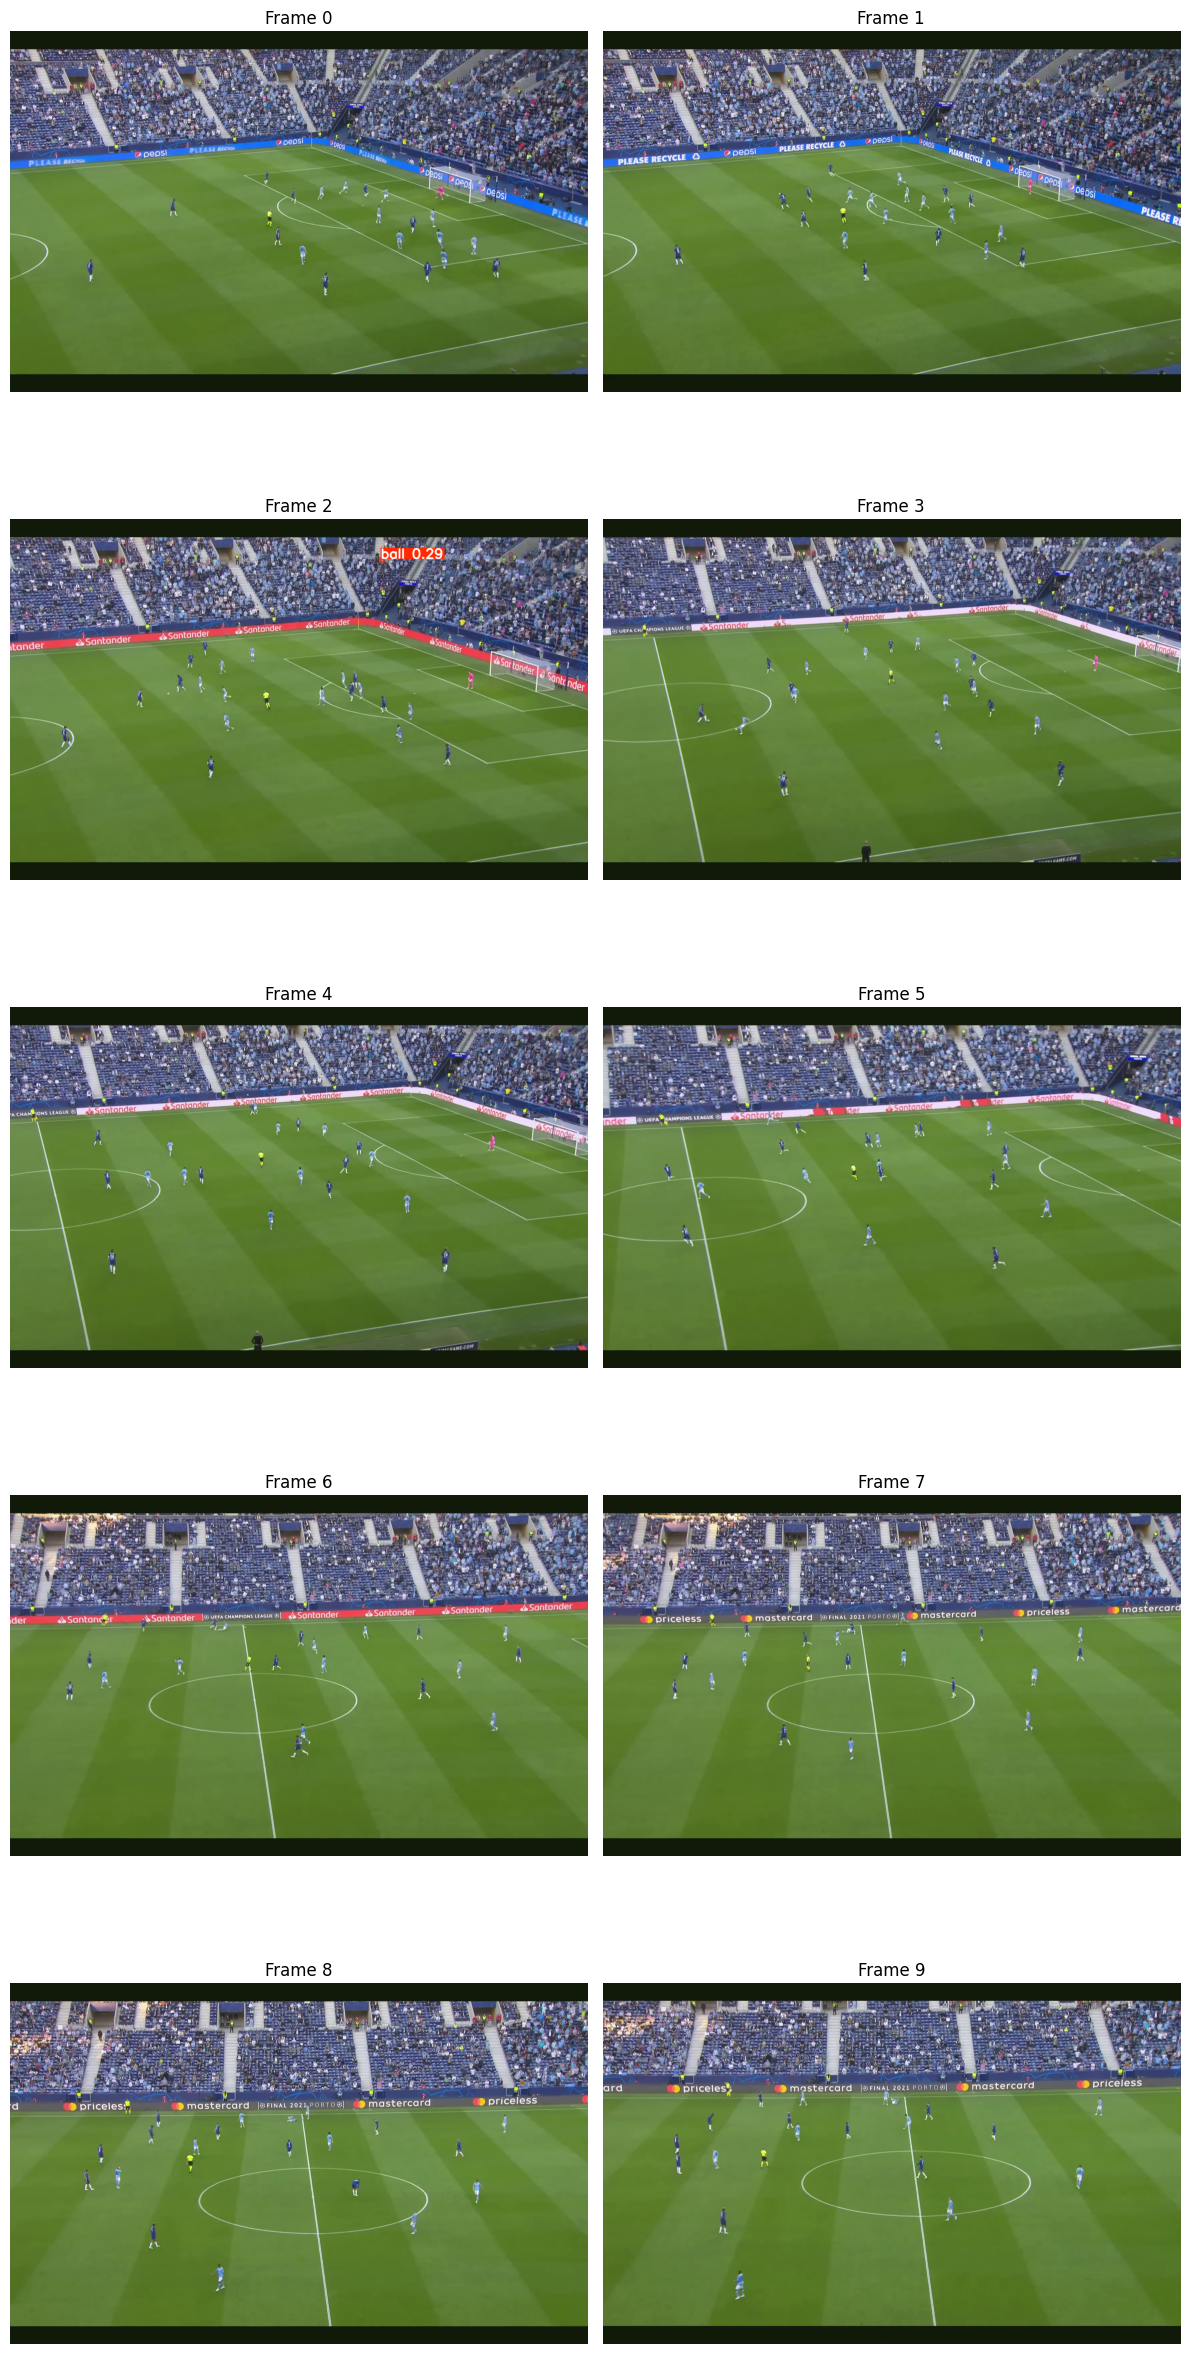

In [5]:
num_frames = len(results)

cols = 2 
rows = (num_frames + cols - 1) // cols

plt.figure(figsize=(12, rows * 5))  # tinggi otomatis ikut jumlah row

for i, result in enumerate(results):
    annotated = result.plot()
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated)
    plt.title(f"Frame {i}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
for i, result in enumerate(results):
    print(f"Frame {i}")
    for box in result.boxes:
        print("  Conf:", float(box.conf))
        print("  Class:", int(box.cls))
        print("  BBox:", box.xyxy.tolist())
    print("------")

Frame 0
------
Frame 1
------
Frame 2
  Conf: 0.287131667137146
  Class: 0
  BBox: [[1108.0499267578125, 119.72200775146484, 1117.8265380859375, 127.2081069946289]]
------
Frame 3
------
Frame 4
------
Frame 5
------
Frame 6
------
Frame 7
------
Frame 8
------
Frame 9
------
